# Домашнее задание 10. Сегментация клиентов банка (German Credit Data)

**Цель:** провести кластеризацию клиентов немецкого банка, чтобы выделить сегменты аудитории и понять, чем они характеризуются.

План работы:
1. EDA и Preprocessing
2. Моделирование (K-Means, Hierarchical, DBSCAN + PCA/t-SNE/UMAP)
3. Интерпретация кластеров

## Часть 1. EDA и Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
import umap

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

### 1.1 Загрузка данных

Датасет German Credit (UCI / Kaggle `uciml/german-credit`) содержит 1000 клиентов немецкого банка, взявших кредит, и их характеристики (демография, тип жилья, накопления, сумма и срок кредита и т.д.).

In [2]:
df = pd.read_csv('german_credit_data.csv', index_col=0)
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
dtypes: int64(4), str(5)
memory usage: 95.9 KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Признаки:**
- `Age` — возраст клиента
- `Sex` — пол
- `Job` — уровень квалификации (0 — unskilled non-resident, 1 — unskilled resident, 2 — skilled, 3 — highly skilled)
- `Housing` — тип жилья (own / rent / free)
- `Saving accounts` — уровень сберегательного счёта (little / moderate / quite rich / rich)
- `Checking account` — уровень текущего счёта (little / moderate / rich)
- `Credit amount` — сумма кредита
- `Duration` — срок кредита (в месяцах)
- `Purpose` — цель кредита

`Job` — по факту уже числовой порядковый признак, остальные категориальные требуют кодирования.

### 1.2 Пропуски

In [5]:
df.isna().sum().to_frame('n_missing').assign(pct=lambda x: (x['n_missing']/len(df)*100).round(1))

,n_missing,pct
Age,0,0.0
Sex,0,0.0
Job,0,0.0
Housing,0,0.0
Saving accounts,183,18.3
Checking account,394,39.4
Credit amount,0,0.0
Duration,0,0.0
Purpose,0,0.0


Пропуски есть только в `Saving accounts` (18.3%) и `Checking account` (39.4%). Судя по формулировке признаков, `NaN` здесь, скорее всего, означает **отсутствие такого счёта**, а не техническую потерю данных — поэтому заполним пропуски отдельной категорией `'none'`, а не медианой/модой.

In [6]:
df['Saving accounts'] = df['Saving accounts'].fillna('none')
df['Checking account'] = df['Checking account'].fillna('none')
df.isna().sum().sum()

np.int64(0)

### 1.3 Распределения числовых признаков

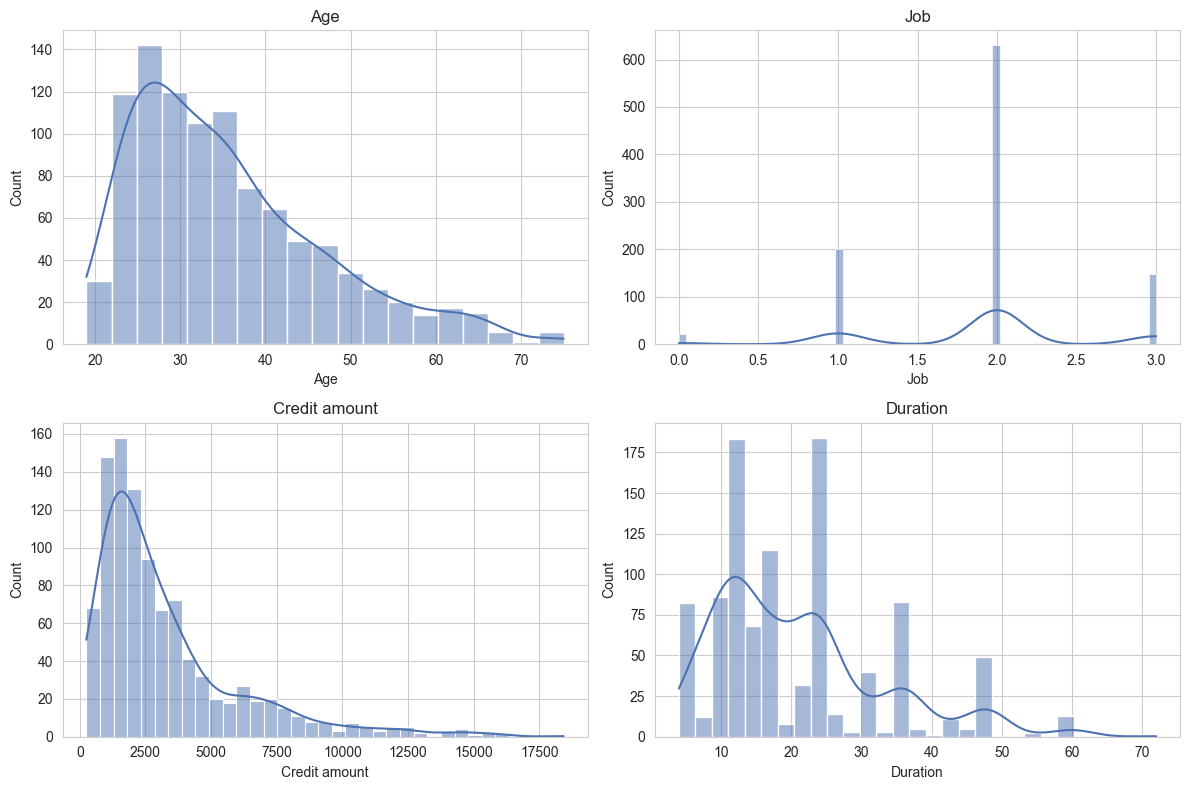

In [7]:
num_cols = ['Age', 'Job', 'Credit amount', 'Duration']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.tight_layout()
plt.show()

`Age` и `Credit amount` смещены вправо (много молодых клиентов и небольших кредитов, но есть длинный хвост пожилых клиентов и крупных сумм). `Duration` также right-skewed. `Job` — почти категориальный (4 уровня, доминирует 2 — skilled).

### 1.4 Категориальные признаки

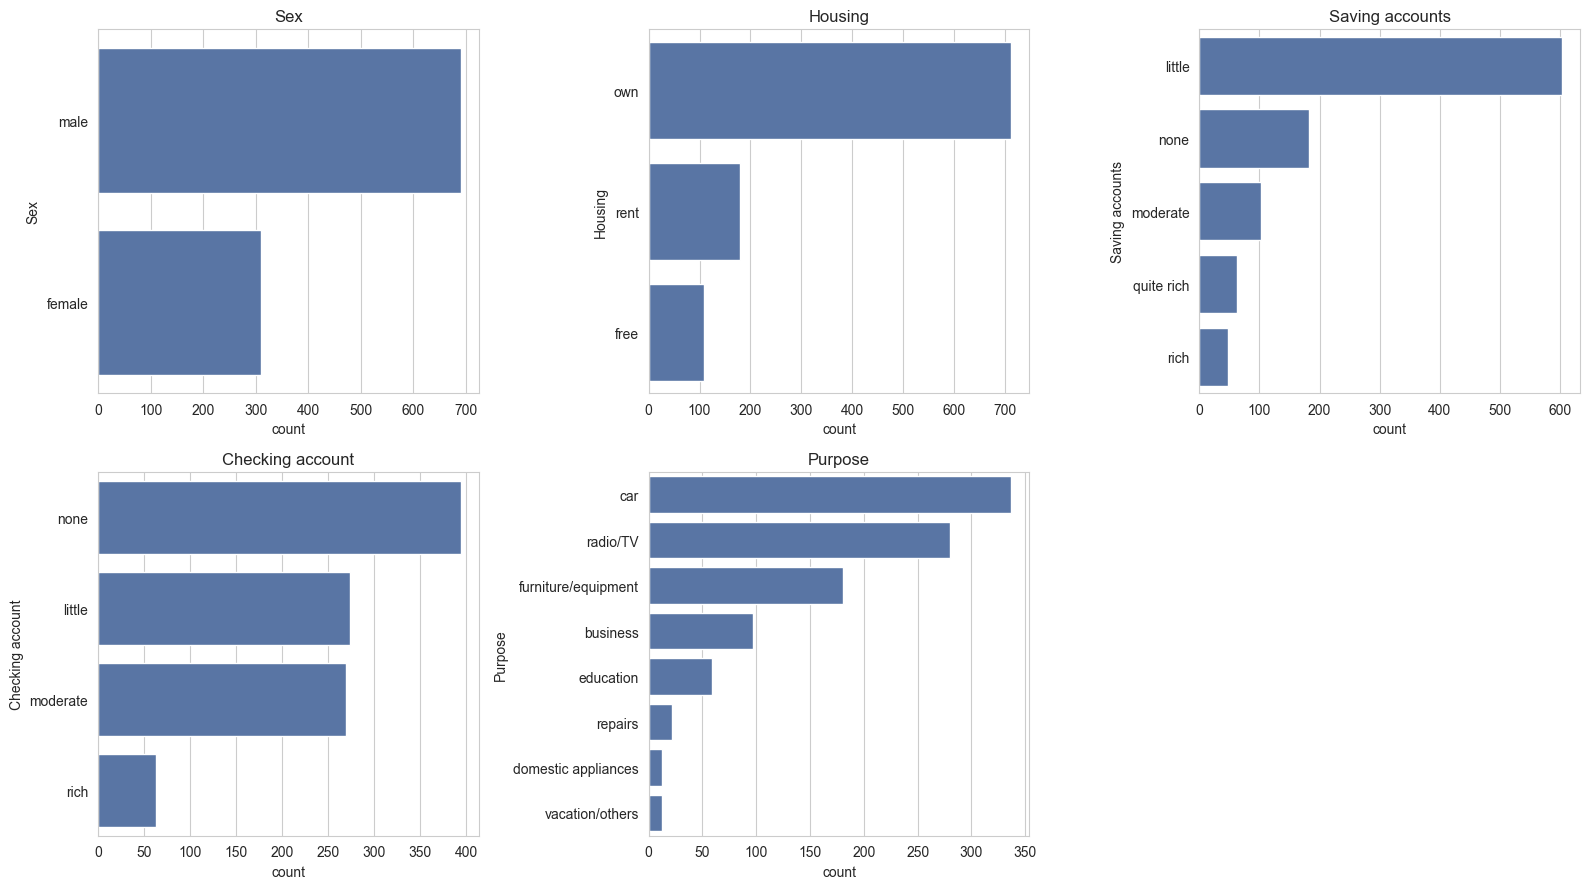

In [8]:
cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, color='#4C72B0')
    ax.set_title(col)
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()

Мужчин почти в 2 раза больше, чем женщин. Большинство клиентов владеют жильём (`own`). У большинства клиентов на сберегательном счету «немного» средств (`little`) либо счёт отсутствует. Самая частая цель кредита — покупка автомобиля и радио/ТВ-техники.

### 1.5 Корреляции числовых признаков

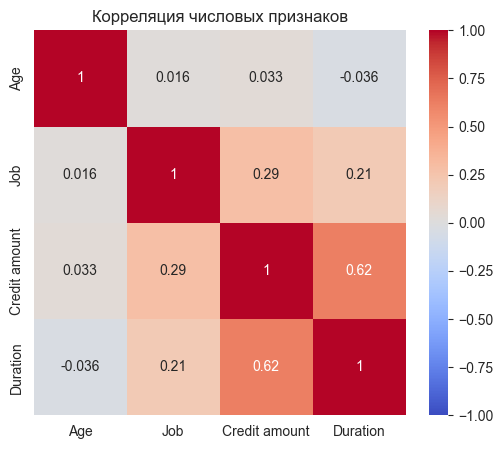

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Корреляция числовых признаков')
plt.show()

Основная зависимость — `Credit amount` и `Duration` коррелируют положительно (0.62): чем больше сумма кредита, тем на больший срок он обычно берётся. Остальные признаки слабо связаны между собой.

### 1.6 Кодирование категориальных признаков

Используем разные стратегии кодирования в зависимости от природы признака:
- **Порядковые** (`Saving accounts`, `Checking account`) — `OrdinalEncoder` с явно заданным порядком уровней (`none < little < moderate < quite rich/rich`), т.к. между категориями есть естественный порядок «больше денег на счету».
- **Бинарный** (`Sex`) — простое отображение 0/1.
- **Номинальные без порядка** (`Housing`, `Purpose`) — One-Hot Encoding, чтобы не вносить в модель несуществующий порядок между категориями.

In [10]:
saving_order = ['none', 'little', 'moderate', 'quite rich', 'rich']
checking_order = ['none', 'little', 'moderate', 'rich']

oe_saving = OrdinalEncoder(categories=[saving_order])
oe_checking = OrdinalEncoder(categories=[checking_order])

df['Saving accounts_enc'] = oe_saving.fit_transform(df[['Saving accounts']])
df['Checking account_enc'] = oe_checking.fit_transform(df[['Checking account']])
df['Sex_enc'] = df['Sex'].map({'male': 0, 'female': 1})

df_model = pd.get_dummies(df, columns=['Housing', 'Purpose'], prefix=['Housing', 'Purpose'])
df_model.head()

,Age,Sex,Job,Saving accounts,Checking account,Credit amount,Duration,Saving accounts_enc,Checking account_enc,Sex_enc,...,Housing_own,Housing_rent,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,male,2,none,little,1169,6,0.0,1.0,0,...,True,False,False,False,False,False,False,True,False,False
1,22,female,2,little,moderate,5951,48,1.0,2.0,1,...,True,False,False,False,False,False,False,True,False,False
2,49,male,1,little,none,2096,12,1.0,0.0,0,...,True,False,False,False,False,True,False,False,False,False
3,45,male,2,little,little,7882,42,1.0,1.0,0,...,False,False,False,False,False,False,True,False,False,False
4,53,male,2,little,little,4870,24,1.0,1.0,0,...,False,False,False,True,False,False,False,False,False,False


In [11]:
feature_cols = (
    ['Age', 'Sex_enc', 'Job', 'Saving accounts_enc', 'Checking account_enc', 'Credit amount', 'Duration']
    + [c for c in df_model.columns if c.startswith('Housing_')]
    + [c for c in df_model.columns if c.startswith('Purpose_')]
)
X = df_model[feature_cols].astype(float)
print(X.shape)
X.head()

(1000, 18)


,Age,Sex_enc,Job,Saving accounts_enc,Checking account_enc,Credit amount,Duration,Housing_free,Housing_own,Housing_rent,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67.0,0.0,2.0,0.0,1.0,1169.0,6.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,22.0,1.0,2.0,1.0,2.0,5951.0,48.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,49.0,0.0,1.0,1.0,0.0,2096.0,12.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,45.0,0.0,2.0,1.0,1.0,7882.0,42.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,53.0,0.0,2.0,1.0,1.0,4870.0,24.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


### 1.7 Масштабирование

Все алгоритмы кластеризации, которые мы будем использовать (K-Means, Agglomerative, DBSCAN), основаны на расстояниях между точками (обычно евклидовых). Если признаки измерены в разных единицах и масштабах — например, `Credit amount` принимает значения от 250 до 18000+, а `Sex_enc` или one-hot признаки — только 0/1 — то признак с большим разбросом начнёт доминировать в расстоянии между точками просто из-за масштаба, а не из-за реальной важности. Поэтому перед кластеризацией все признаки приводятся к одному масштабу (среднее 0, дисперсия 1) с помощью `StandardScaler`.

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)
X_scaled.describe().T[['mean', 'std', 'min', 'max']].round(2)

,mean,std,min,max
Age,0.0,1.0,-1.46,3.47
Sex_enc,-0.0,1.0,-0.67,1.49
Job,0.0,1.0,-2.91,1.68
Saving accounts_enc,0.0,1.0,-1.23,2.91
Checking account_enc,0.0,1.0,-1.05,2.09
Credit amount,0.0,1.0,-1.07,5.37
Duration,0.0,1.0,-1.40,4.24
Housing_free,0.0,1.0,-0.35,2.87
Housing_own,0.0,1.0,-1.58,0.63
Housing_rent,-0.0,1.0,-0.47,2.14


## Часть 2. Моделирование

Построим три варианта кластеризации и для каждого подберём оптимальное число кластеров с помощью Elbow method / Silhouette.

### 2.1 K-Means

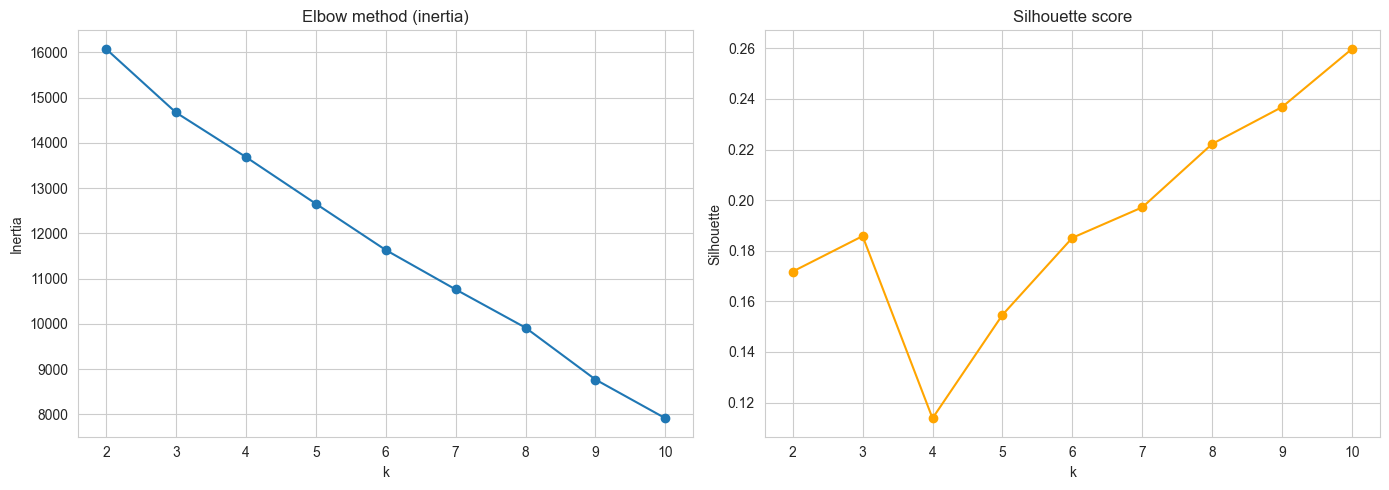

In [13]:
inertias = []
sil_scores_km = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores_km.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Elbow method (inertia)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores_km, marker='o', color='orange')
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

На Elbow-графике явного «излома» не видно (инерция снижается плавно) — типичная ситуация для смешанных данных с one-hot признаками. Silhouette score имеет локальный максимум при **k=3**, после чего проседает и снова растёт за счёт дробления на мелкие, менее интерпретируемые группы. Выбираем **k=3** как компромисс между качеством разделения и интерпретируемостью.

In [14]:
k_kmeans = 3
kmeans = KMeans(n_clusters=k_kmeans, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)
df['cluster_kmeans'] = labels_kmeans
pd.Series(labels_kmeans).value_counts().sort_index()

0    179
1    114
2    707
Name: count, dtype: int64

### 2.2 Hierarchical Clustering (Agglomerative)

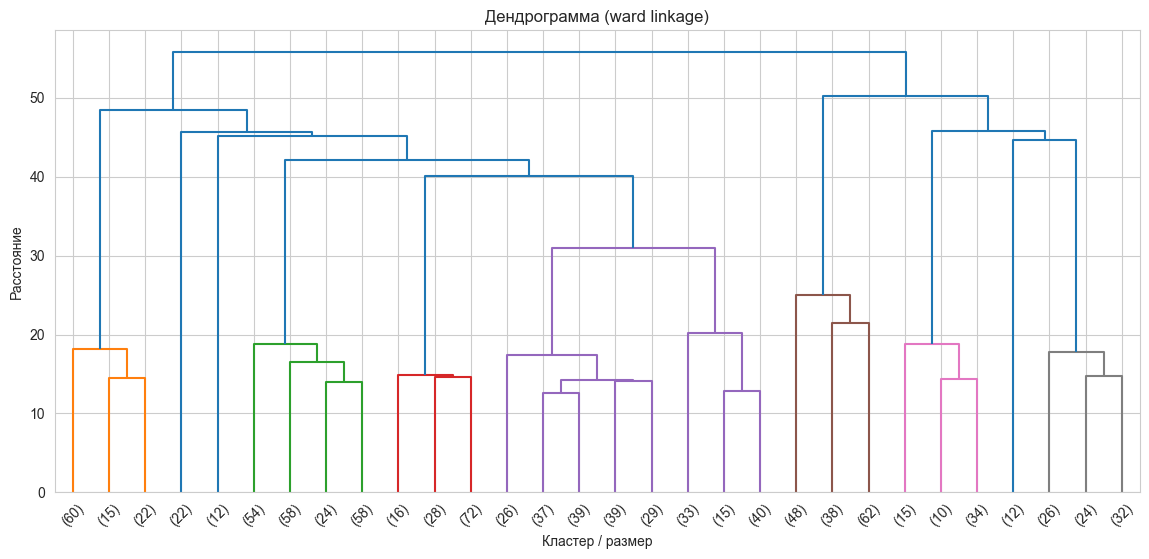

In [15]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.title('Дендрограмма (ward linkage)')
plt.xlabel('Кластер / размер')
plt.ylabel('Расстояние')
plt.show()

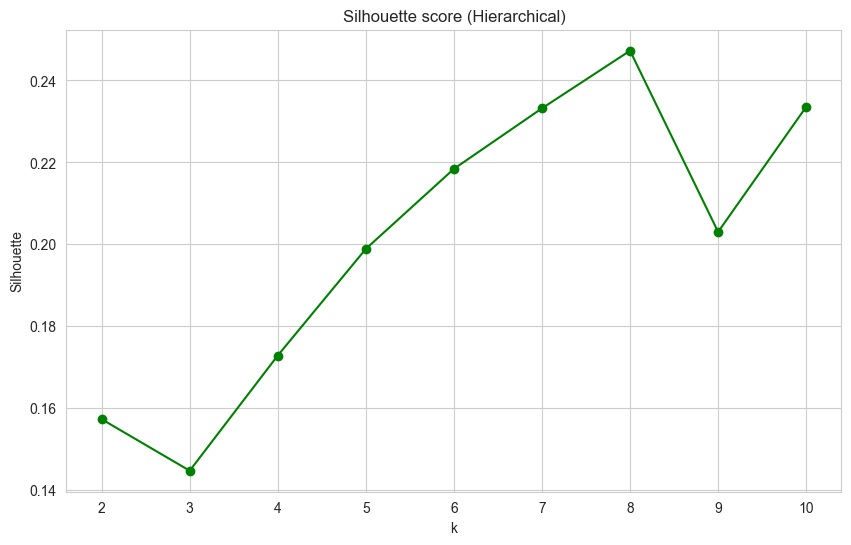

In [16]:
sil_scores_hc = []
for k in K_range:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_scaled)
    sil_scores_hc.append(silhouette_score(X_scaled, labels))

plt.plot(list(K_range), sil_scores_hc, marker='o', color='green')
plt.title('Silhouette score (Hierarchical)')
plt.xlabel('k')
plt.ylabel('Silhouette')
plt.show()

И дендрограмма, и silhouette-график указывают на разумное разделение при небольшом числе кластеров. Возьмём **k=3**, чтобы результат было сопоставимо интерпретировать с K-Means.

In [17]:
k_hc = 3
hc_model = AgglomerativeClustering(n_clusters=k_hc, linkage='ward')
labels_hc = hc_model.fit_predict(X_scaled)
df['cluster_hc'] = labels_hc
pd.Series(labels_hc).value_counts().sort_index()

0    699
1    153
2    148
Name: count, dtype: int64

### 2.3 DBSCAN

Для DBSCAN нужно подобрать `eps` и `min_samples`. Используем k-distance plot (расстояние до k-го соседа, отсортированное по возрастанию) — «излом» графика подсказывает разумное значение `eps`.

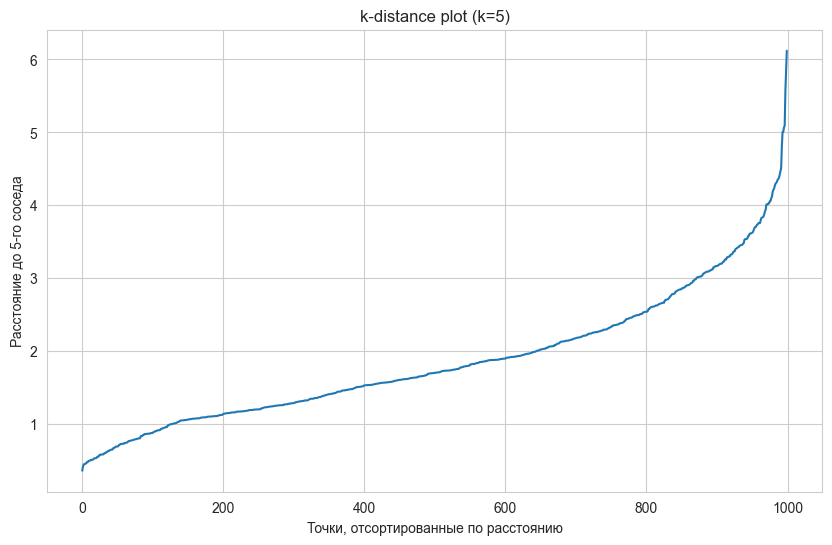

In [18]:
min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.plot(k_distances)
plt.title(f'k-distance plot (k={min_samples})')
plt.xlabel('Точки, отсортированные по расстоянию')
plt.ylabel(f'Расстояние до {min_samples}-го соседа')
plt.show()

In [19]:
eps_range = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
results = []
for eps in eps_range:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    sil = silhouette_score(X_scaled, labels) if n_clusters > 1 else np.nan
    results.append((eps, n_clusters, n_noise, sil))

pd.DataFrame(results, columns=['eps', 'n_clusters', 'n_noise', 'silhouette'])

,eps,n_clusters,n_noise,silhouette
0,1.5,19,507,-0.076817
1,2.0,18,257,0.083380
2,2.5,12,139,0.223616
3,3.0,18,58,0.255284
4,3.5,9,18,0.204377
5,4.0,5,9,0.246227


Оптимальным выглядит **eps=3.0** — даёт наибольший silhouette score при приемлемом числе кластеров и не слишком большом количестве шумовых точек. Обратите внимание: DBSCAN сам определяет число кластеров и, в отличие от K-Means/Hierarchical, часть точек помечает как шум (выбросы) — это ожидаемо для данных без чёткой шаровой структуры.

In [20]:
db_model = DBSCAN(eps=3.0, min_samples=min_samples)
labels_dbscan = db_model.fit_predict(X_scaled)
df['cluster_dbscan'] = labels_dbscan
pd.Series(labels_dbscan).value_counts().sort_index()

-1      58
 0     225
 1      34
 2      50
 3     122
 4      62
 5     217
 6      11
 7      75
 8      36
 9       7
 10     15
 11     48
 12      9
 13     12
 14      7
 15      5
 16      3
 17      4
Name: count, dtype: int64

### 2.4 Снижение размерности и визуализация

Признаковое пространство после one-hot кодирования многомерно (18 признаков) и не поддаётся прямой визуализации. Спроецируем его в 2D тремя способами: **PCA** (линейный, сохраняет глобальную дисперсию), **t-SNE** и **UMAP** (нелинейные, лучше сохраняют локальную структуру / кластеры).

In [21]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print('Explained variance ratio:', pca.explained_variance_ratio_, 'sum:', pca.explained_variance_ratio_.sum())

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
X_umap = reducer.fit_transform(X_scaled)

Explained variance ratio: [0.12507769 0.10799169] sum: 0.2330693822530044


C:\Users\user1\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


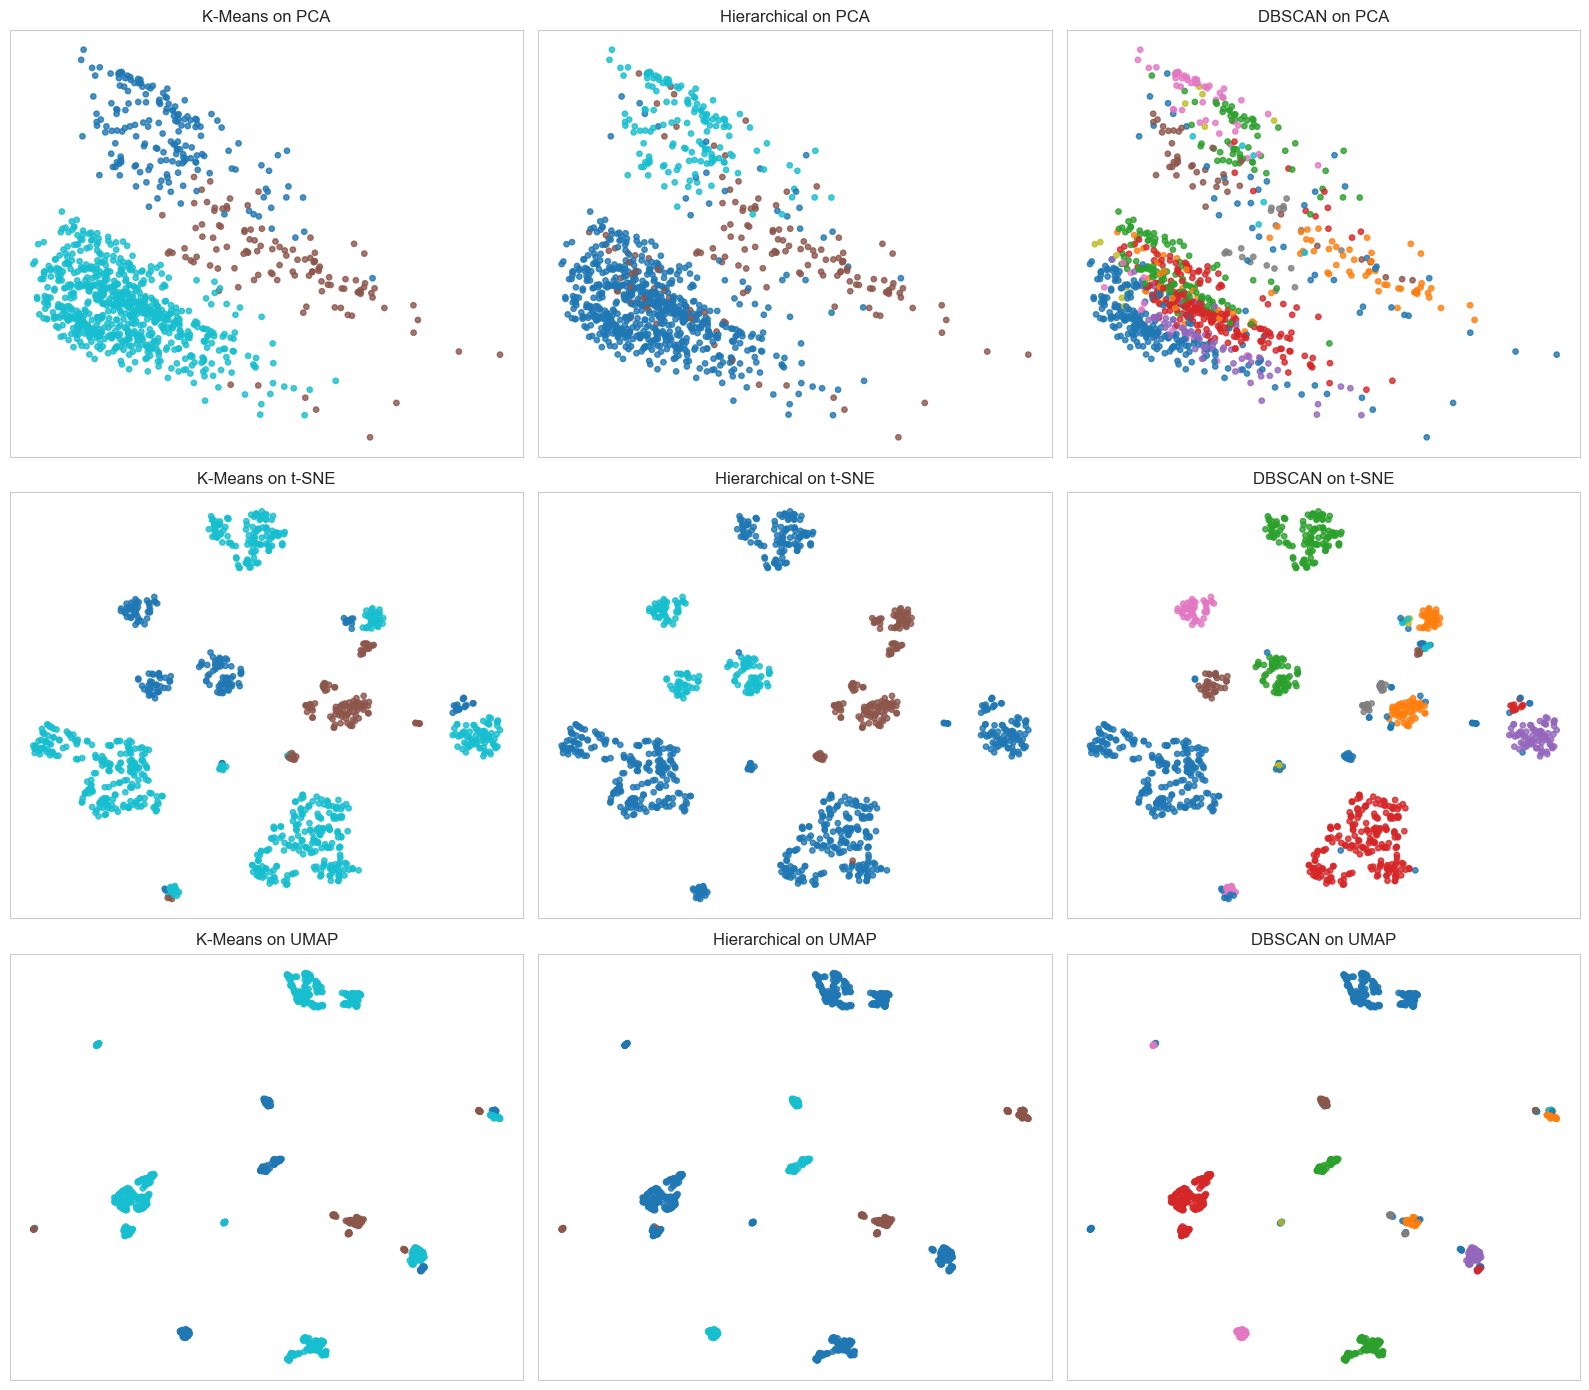

In [22]:
projections = {'PCA': X_pca, 't-SNE': X_tsne, 'UMAP': X_umap}
clusterings = {
    'K-Means': labels_kmeans,
    'Hierarchical': labels_hc,
    'DBSCAN': labels_dbscan,
}

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for i, (proj_name, proj) in enumerate(projections.items()):
    for j, (clust_name, labels) in enumerate(clusterings.items()):
        ax = axes[i, j]
        sc = ax.scatter(proj[:, 0], proj[:, 1], c=labels, cmap='tab10', s=15, alpha=0.8)
        ax.set_title(f'{clust_name} on {proj_name}')
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

UMAP и t-SNE лучше разделяют локальные группы визуально, чем PCA (в PCA первые 2 компоненты объясняют лишь ~23% дисперсии — сказывается большое число разреженных one-hot признаков). K-Means и Hierarchical дают похожие по структуре разбиения (что ожидаемо — оба ищут компактные шаровидные кластеры), DBSCAN выделяет более плотные ядра и явно помечает часть точек как выбросы (шум).

## Часть 3. Интерпретация

Для интерпретации возьмём результат **K-Means (k=3)** — самый устойчивый и интерпретируемый вариант из построенных.

### 3.1 Средние значения признаков по кластерам

In [23]:
profile_cols = ['Age', 'Job', 'Credit amount', 'Duration', 'Saving accounts_enc', 'Checking account_enc']
cluster_means = df.groupby('cluster_kmeans')[profile_cols].mean().round(2)
cluster_means['size'] = df['cluster_kmeans'].value_counts().sort_index()
cluster_means

,Age,Job,Credit amount,Duration,Saving accounts_enc,Checking account_enc,size
cluster_kmeans,,,,,,,
0,30.37,1.85,3122.55,19.24,1.24,1.03,179
1,43.35,2.20,5220.09,27.59,1.04,1.13,114
2,35.60,1.87,2994.67,20.25,1.20,0.97,707


In [24]:
cat_profile_cols = ['Sex', 'Housing', 'Purpose']
for col in cat_profile_cols:
    print(f'--- {col} (доли внутри кластера) ---')
    print((df.groupby('cluster_kmeans')[col].value_counts(normalize=True)
           .unstack().round(2).fillna(0)))
    print()

--- Sex (доли внутри кластера) ---
Sex             female  male
cluster_kmeans              
0                 0.53  0.47
1                 0.18  0.82
2                 0.28  0.72

--- Housing (доли внутри кластера) ---
Housing         free   own  rent
cluster_kmeans                  
0               0.00  0.00   1.0
1               0.95  0.05   0.0
2               0.00  1.00   0.0

--- Purpose (доли внутри кластера) ---
Purpose         business   car  domestic appliances  education  \
cluster_kmeans                                                   
0                   0.09  0.35                 0.01       0.06   
1                   0.04  0.48                 0.00       0.13   
2                   0.11  0.31                 0.01       0.05   

Purpose         furniture/equipment  radio/TV  repairs  vacation/others  
cluster_kmeans                                                           
0                              0.27      0.21     0.01             0.00  
1                     

**Наблюдения по средним значениям** (конкретные цифры см. в таблицах выше):
- Кластеры заметно различаются по `Credit amount` и `Duration` — один сегмент выделяется существенно более крупными и длинными кредитами, что обычно означает более высокий финансовый риск для банка.
- `Saving accounts_enc` / `Checking account_enc` (уровень накоплений) различается между кластерами — группа с крупными кредитами при этом не всегда имеет более высокие остатки на счетах, что может говорить о повышенной долговой нагрузке.
- `Age` и `Job` расходятся между кластерами слабее — демография не является главным фактором разделения, основную роль играют кредитные характеристики.

### 3.2 Boxplot-ы признаков по кластерам

C:\Users\user1\AppData\Local\Temp\ipykernel_28396\632353749.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_kmeans', y=col, data=df, ax=ax, palette='tab10')


C:\Users\user1\AppData\Local\Temp\ipykernel_28396\632353749.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_kmeans', y=col, data=df, ax=ax, palette='tab10')


C:\Users\user1\AppData\Local\Temp\ipykernel_28396\632353749.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_kmeans', y=col, data=df, ax=ax, palette='tab10')


C:\Users\user1\AppData\Local\Temp\ipykernel_28396\632353749.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_kmeans', y=col, data=df, ax=ax, palette='tab10')


C:\Users\user1\AppData\Local\Temp\ipykernel_28396\632353749.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_kmeans', y=col, data=df, ax=ax, palette='tab10')


C:\Users\user1\AppData\Local\Temp\ipykernel_28396\632353749.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_kmeans', y=col, data=df, ax=ax, palette='tab10')


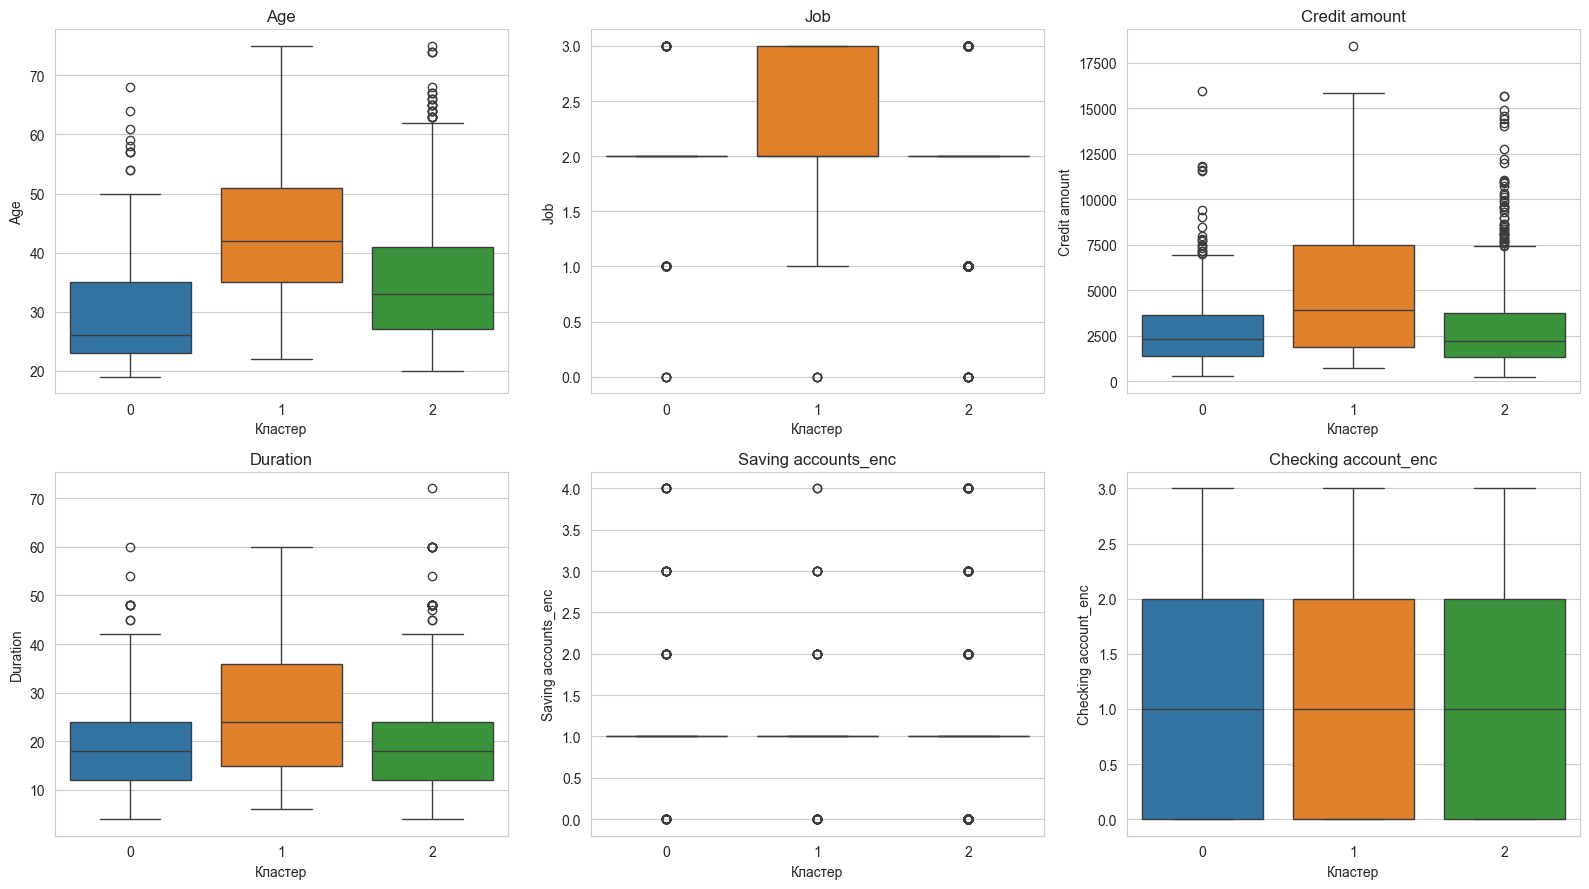

In [25]:
box_cols = ['Age', 'Job', 'Credit amount', 'Duration', 'Saving accounts_enc', 'Checking account_enc']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), box_cols):
    sns.boxplot(x='cluster_kmeans', y=col, data=df, ax=ax, palette='tab10')
    ax.set_title(col)
    ax.set_xlabel('Кластер')
plt.tight_layout()
plt.show()

**Наибольшее отличие между кластерами** видно по `Credit amount` и `Duration` — их межквартильные размахи почти не пересекаются между «крупным» кластером и остальными. Это самые интерпретируемые и практически полезные признаки: они позволяют банку выделить сегмент клиентов с большими и длинными кредитами (потенциально более рискованный/маржинальный сегмент, требующий более тщательного скоринга) на фоне клиентов с небольшими краткосрочными кредитами (низкий риск, вероятно — повседневные покупки).

По `Saving accounts_enc` и `Checking account_enc` кластеры также различимы, но не так резко: заметно, что сегмент с крупными кредитами не обязательно обладает более высокими остатками на счетах — комбинация «большой кредит + скромные накопления» интерпретируется как более рискованная группа.

`Age` и `Job` показывают широкое перекрытие межквартильных размахов между кластерами — по этим признакам сегменты значимо не различаются, то есть кластеризация в первую очередь отражает **финансовое поведение** клиента (сумма/срок кредита, состояние счетов), а не демографию.

### 3.3 Итоговые выводы

1. Кластеризация клиентов немецкого банка на 3 сегмента (K-Means, подтверждено Hierarchical) стабильно выделяет группу клиентов с **крупными и долгосрочными кредитами**, отличающуюся от остальных заметнее всего.
2. Признаки `Credit amount` и `Duration` — главные драйверы разделения на кластеры; накопления на счетах — вторичный, но также значимый фактор.
3. Демографические признаки (`Age`, `Sex`, `Job`) слабо различают сегменты — сегментация в первую очередь описывает поведение клиента как заёмщика, а не его личные характеристики.
4. DBSCAN дополнительно подсвечивает нестандартных клиентов (шум) — их стоит рассматривать отдельно, как потенциальные аномалии или редкие профили, не подходящие ни под один типичный сегмент.
5. С точки зрения банка такая сегментация может использоваться для дифференциации кредитной политики: более строгий скоринг и мониторинг для сегмента с крупными кредитами и низкими остатками на счетах, более мягкие условия — для сегмента с небольшими краткосрочными кредитами.